[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/colab-version/L05/L05_constrained_to_unconstrained.ipynb)

# From Constrained to Unconstrained: The Substitution Method
### MECH 559 - Systems Optimization - L05
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

Companion notebook to the "Continuous unconstrained optimization" lecture. It works through the cylinder example from the slides end to end: setting up a constrained problem, eliminating the active constraint by substitution, and then checking - numerically - whether the resulting stationary point of the unconstrained problem is actually a minimizer.

## Learning objectives

By the end, students should be able to:

1. Explain why unconstrained optimization is worth studying even though most engineering problems are constrained.
2. Eliminate an active inequality constraint by substitution to reduce a constrained problem to an unconstrained one.
3. Cross-check a substituted (reduced) problem against the original constrained problem numerically.
4. Recognize that finding a stationary point via substitution is not the end of the story: it still has to be checked with the first- and second-order conditions covered later in this lecture.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

---
## 1. Why bother with unconstrained optimization?

Even though engineering design problems are typically constrained, unconstrained optimization is still central because:

- it is the foundation the theory of constrained optimization is built on;
- some engineering problems - e.g. solving a system of nonlinear equations, or a least-squares fit - are naturally unconstrained problems;
- univariate unconstrained optimization is exactly the "line search" subproblem used inside most constrained-optimization algorithms;
- constrained problems can sometimes be reformulated as unconstrained ones, either exactly (substitution, this notebook) or approximately (penalty methods, covered later in the course).

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq, minimize, minimize_scalar

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"feasible": "#A8DADC", "boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49"}

print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 2. The cylinder problem

$$
\begin{aligned}
\underset{r,\,h}{\text{minimize}} \quad & f(r,h) = -2\pi r^2 - 2\pi r h\\
\text{subject to} \quad & g(r,h) = \pi r^2 h - 1 \leq 0, \qquad r,h > 0
\end{aligned}
$$

$-f(r,h)$ is the total surface area of a cylinder of radius $r$ and height $h$ (two ends plus the lateral surface), so minimizing $f$ means **maximizing surface area** while the volume $\pi r^2 h$ stays at or below $1$.

> **Predict:** with only an *upper* bound on volume and no bound on $r$ or $h$ individually, can surface area be pushed arbitrarily high while staying feasible? Sketch what a "thin pancake" cylinder ($r$ large, $h$ small) does to volume and area before running the next cell.

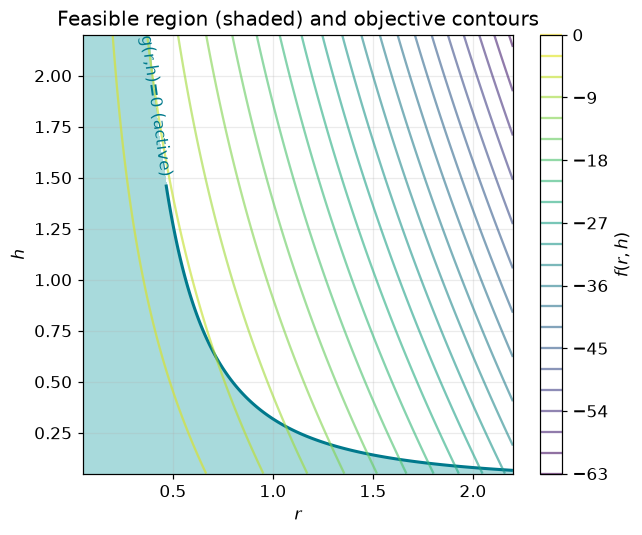

Along the shaded region's boundary the volume constraint is active (V = 1).
Moving along that boundary toward large r, small h stays feasible but pushes f more negative:
  r= 0.30, h= 3.5368 (V=1): f =     -7.232
  r= 1.00, h= 0.3183 (V=1): f =     -8.283
  r= 3.00, h= 0.0354 (V=1): f =    -57.215
  r=10.00, h= 0.0032 (V=1): f =   -628.519


In [10]:
r = np.linspace(0.05, 2.2, 400)
h = np.linspace(0.05, 2.2, 400)
R, H = np.meshgrid(r, h)
G = np.pi * R**2 * H - 1
F = -2 * np.pi * R**2 - 2 * np.pi * R * H

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(R, H, G <= 0, levels=[-0.5, 0.5, 1.5], colors=["white", COLORS["feasible"]])
active = ax.contour(R, H, G, levels=[0], colors=COLORS["boundary"], linewidths=2)
ax.clabel(active, fmt={0: "g(r,h)=0 (active)"})
contours = ax.contour(R, H, F, levels=20, cmap="viridis", alpha=0.6)
ax.set(xlabel="$r$", ylabel="$h$", title="Feasible region (shaded) and objective contours")
plt.colorbar(contours, ax=ax, label="$f(r,h)$")
plt.tight_layout()
plt.show()

print("Along the shaded region's boundary the volume constraint is active (V = 1).")
print("Moving along that boundary toward large r, small h stays feasible but pushes f more negative:")
for r_probe in [0.3, 1.0, 3.0, 10.0]:
    h_probe = 1 / (np.pi * r_probe**2)
    f_probe = -2*np.pi*r_probe**2 - 2*np.pi*r_probe*h_probe
    print(f"  r={r_probe:5.2f}, h={h_probe:7.4f} (V=1): f = {f_probe:10.3f}")

---
## 3. Substitution: eliminate the active constraint

At the optimum we expect the volume constraint to be active (otherwise we could grow the cylinder for free), so set $g(r,h)=0$:

$$
\pi r^2 h = 1 \quad \Longrightarrow \quad h = \frac{1}{\pi r^2}.
$$

Substituting into $f$ eliminates $h$ and turns the constrained problem into the **unconstrained** one from the slide:

$$
\underset{r}{\text{minimize}} \quad f(r) = -2\pi r^2 - \frac{2\pi r}{\pi r^2} = -2\pi r^2 - \frac{2}{r}.
$$

Apply the univariate FONC from this lecture, $f'(r^\ast) = 0$:

$$
f'(r) = -4\pi r + \frac{2}{r^2} = 0 \quad \Longrightarrow \quad r^{\ast 3} = \frac{1}{2\pi}.
$$

closed-form  r* = 0.541926
root-finder  r* = 0.541926  (matches)
h* = 1/(pi r*^2) = 1.083852
f(r*) = -5.535810


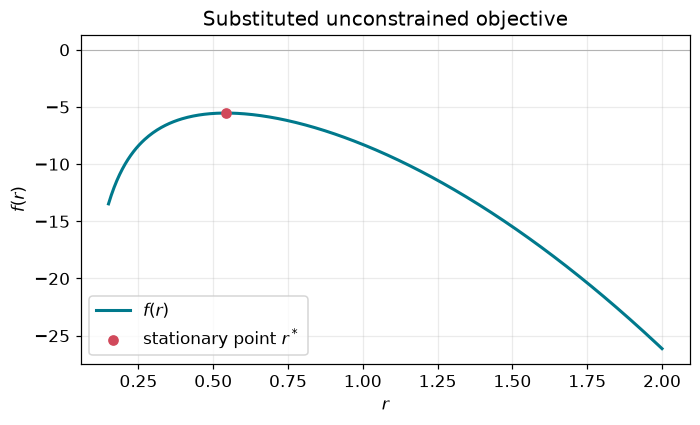

In [11]:
def f_r(r):
    return -2 * np.pi * r**2 - 2 / r

def f_prime(r):
    return -4 * np.pi * r + 2 / r**2

def f_double_prime(r):
    return -4 * np.pi - 4 / r**3

r_star_closed = (1 / (2 * np.pi)) ** (1 / 3)
r_star_numeric = brentq(f_prime, 0.1, 2.0)
assert np.isclose(r_star_closed, r_star_numeric)
h_star = 1 / (np.pi * r_star_numeric**2)

print(f"closed-form  r* = {r_star_closed:.6f}")
print(f"root-finder  r* = {r_star_numeric:.6f}  (matches)")
print(f"h* = 1/(pi r*^2) = {h_star:.6f}")
print(f"f(r*) = {f_r(r_star_numeric):.6f}")

rr = np.linspace(0.15, 2.0, 400)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(rr, f_r(rr), color=COLORS["boundary"], lw=2, label="$f(r)$")
ax.scatter([r_star_numeric], [f_r(r_star_numeric)], color=COLORS["optimum"], zorder=3,
           label="stationary point $r^*$")
ax.axhline(0, color="0.7", lw=0.7)
ax.set(xlabel="$r$", ylabel="$f(r)$", title="Substituted unconstrained objective")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Is $r^\ast$ actually a minimizer? Apply the SOSC

Finding a stationary point is only the *first-order necessary* condition. This lecture's *second-order sufficient* condition asks for the curvature at $r^\ast$:

$$
f''(r) = -4\pi - \frac{4}{r^3} < 0 \quad \text{for every } r>0.
$$

$f$ is **strictly concave everywhere** on $r>0$, so its one stationary point is a **local maximum**, not a minimum - and since $f(r)\to-\infty$ both as $r\to0^+$ and as $r\to\infty$, $f$ has **no minimum at all** on $r>0$: it is unbounded below.

This is exactly consistent with the contour plot in Section 2: moving along the active-constraint boundary toward large $r$ (a thin pancake) drives $f$ to $-\infty$. Substitution correctly removed the constraint, but it did not - and cannot by itself - guarantee that the resulting stationary point solves the *minimization* problem as posed. That check is exactly what FONCs/SOSCs (this lecture) are for.

f''(r*) = -37.699  -> negative, so r* is a LOCAL MAXIMUM of f(r)
  f(   0.001) =     -2,000.000
  f(     0.1) =        -20.063
  f(       1) =         -8.283
  f(      10) =       -628.519
  f(   1e+03) = -6,283,185.309
f(r) -> -infinity at both ends: the substituted problem is unbounded below.


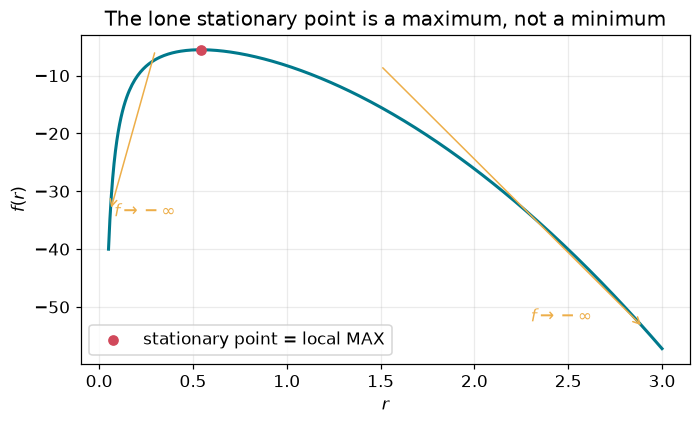

In [12]:
print(f"f''(r*) = {f_double_prime(r_star_numeric):.3f}  -> negative, so r* is a LOCAL MAXIMUM of f(r)")

r_extreme = np.array([1e-3, 1e-1, 1.0, 10.0, 1e3])
for r_val in r_extreme:
    print(f"  f({r_val:>8.3g}) = {f_r(r_val):>14,.3f}")
print("f(r) -> -infinity at both ends: the substituted problem is unbounded below.")

rr = np.linspace(0.05, 3.0, 400)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(rr, f_r(rr), color=COLORS["boundary"], lw=2)
ax.scatter([r_star_numeric], [f_r(r_star_numeric)], color=COLORS["optimum"], zorder=3,
           label="stationary point = local MAX")
ax.annotate("", xy=(0.06, f_r(0.06)), xytext=(0.3, f_r(0.5)),
            arrowprops=dict(arrowstyle="->", color=COLORS["accent"]))
ax.annotate("", xy=(2.9, f_r(2.9)), xytext=(1.5, f_r(1.0)),
            arrowprops=dict(arrowstyle="->", color=COLORS["accent"]))
ax.text(0.08, f_r(0.06) - 1, r"$f\to-\infty$", color=COLORS["accent"])
ax.text(2.3, f_r(2.9) + 1, r"$f\to-\infty$", color=COLORS["accent"])
ax.set(xlabel="$r$", ylabel="$f(r)$", title="The lone stationary point is a maximum, not a minimum")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Making it a well-posed *minimization*: flip to actual surface area

The slide's sign convention makes the objective "minimize $-(\text{area})$," which is really a disguised maximization and is unbounded, as shown above. The classic, well-posed engineering version of this problem instead **minimizes the actual surface area** for a volume that must reach at least $1$:

$$
\underset{r}{\text{minimize}} \quad s(r) = 2\pi r^2 + \frac{2}{r}, \qquad s(r) = -f(r).
$$

Its second derivative $s''(r) = 4\pi + 4/r^3 > 0$ for all $r>0$: $s$ is **strictly convex**, so its one stationary point (the same $r^\ast$ as before, since $s=-f$) is now a genuine, unique **global minimizer**. We verify this three ways: closed form, a 1-D numerical solver, and the *original* 2-variable constrained problem.

In [13]:
def s(r):
    return 2 * np.pi * r**2 + 2 / r

def s_double_prime(r):
    return 4 * np.pi + 4 / r**3

print(f"s''(r) > 0 for all r>0? {np.all(s_double_prime(np.linspace(0.01, 100, 1000)) > 0)}  -> s is convex")

result_1d = minimize_scalar(s, bounds=(0.01, 5), method="bounded")
print(f"1-D solver:         r* = {result_1d.x:.6f},  s(r*) = {result_1d.fun:.6f}")
print(f"closed form:        r* = {r_star_numeric:.6f},  s(r*) = {s(r_star_numeric):.6f}")

def surface_area(x):
    r_var, h_var = x
    return 2 * np.pi * r_var**2 + 2 * np.pi * r_var * h_var

volume_active = {"type": "ineq", "fun": lambda x: np.pi * x[0]**2 * x[1] - 1}  # V >= 1
result_2d = minimize(surface_area, x0=[1.0, 1.0], bounds=[(1e-3, None), (1e-3, None)],
                      constraints=[volume_active])
print(f"original 2-var NLP: r*={result_2d.x[0]:.6f}, h*={result_2d.x[1]:.6f}, area*={result_2d.fun:.6f}")
assert np.isclose(result_2d.x[0], r_star_numeric, atol=1e-3)
assert np.isclose(result_2d.x[1], h_star, atol=1e-3)
print("Substitution and the original constrained solver agree.")

s''(r) > 0 for all r>0? True  -> s is convex
1-D solver:         r* = 0.541927,  s(r*) = 5.535810
closed form:        r* = 0.541926,  s(r*) = 5.535810
original 2-var NLP: r*=0.541926, h*=1.083852, area*=5.535810
Substitution and the original constrained solver agree.


---
## 6. Interactive: how does the optimum scale with target volume?

For a general target volume $V$, the same derivation gives $r^\ast=(V/2\pi)^{1/3}$. Move the slider and watch $r^\ast$, $h^\ast$, and the minimum surface area respond.

In [14]:
def volume_demo(V=1.0):
    r_v = (V / (2 * np.pi)) ** (1 / 3)
    h_v = V / (np.pi * r_v**2)
    area_v = 2 * np.pi * r_v**2 + 2 * np.pi * r_v * h_v
    rr = np.linspace(0.1, 2.5, 300)
    hh = V / (np.pi * rr**2)
    areas = 2 * np.pi * rr**2 + 2 * np.pi * rr * hh
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(rr, areas, color=COLORS["boundary"], lw=2)
    ax.scatter([r_v], [area_v], color=COLORS["optimum"], zorder=3)
    ax.set(xlabel="$r$", ylabel="surface area on $V=$ const.", title=f"V = {V:.2f}")
    plt.tight_layout()
    plt.show()
    print(f"r* = {r_v:.4f}, h* = {h_v:.4f}, minimum area = {area_v:.4f}")

if WIDGETS_AVAILABLE:
    display(widgets.interactive(volume_demo, V=widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1)))
else:
    print("ipywidgets is not installed; running the default case.")
    volume_demo()

interactive(children=(FloatSlider(value=1.0, description='V', max=3.0, min=0.2), Output()), _dom_classes=('wid…

---
## Takeaways

1. Substitution using an active constraint is an exact way to turn a constrained problem into an unconstrained one - but only for the algebra; it says nothing about optimality.
2. A stationary point found this way must still be checked with FONC/SOSC: here it turned out to be a maximizer, and the "minimize $-\text{area}$" problem is unbounded below.
3. Flipping the sign to minimize the actual surface area gives a strictly convex, well-posed problem whose unique stationary point is the global minimizer - confirmed by an independent constrained NLP solve.
4. Numerically cross-checking a reduced/substituted model against the original formulation is good practice whenever you eliminate variables by hand.

## Optional exercises

1. Repeat the substitution the other way: solve the active constraint for $r$ in terms of $h$ and eliminate $r$ instead. Confirm you get the same optimal cylinder.
2. Add a second constraint $r \le r_{\max}$ to the original "maximize area" formulation. Does a finite maximizer now exist? Find it for $r_{\max}=1$.
3. For the well-posed area-minimization problem, derive the SOSC (convexity) argument directly in $(r,h)$ space using the Hessian of the Lagrangian, instead of substituting first. (Preview of the constrained-optimization lectures.)